In [2]:
import glob
import os
import sys
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import matplotlib.cm as cm

cmap = cm.inferno

# load data from parquet files
experiment_df = pl.read_parquet('./Results/optimisation_experiments.parquet')
best_policy_df = pl.read_parquet('./Results/optimisation_best_policies.parquet')
outcomes_df = pl.read_parquet('./Results/optimisation_outcomes.parquet')

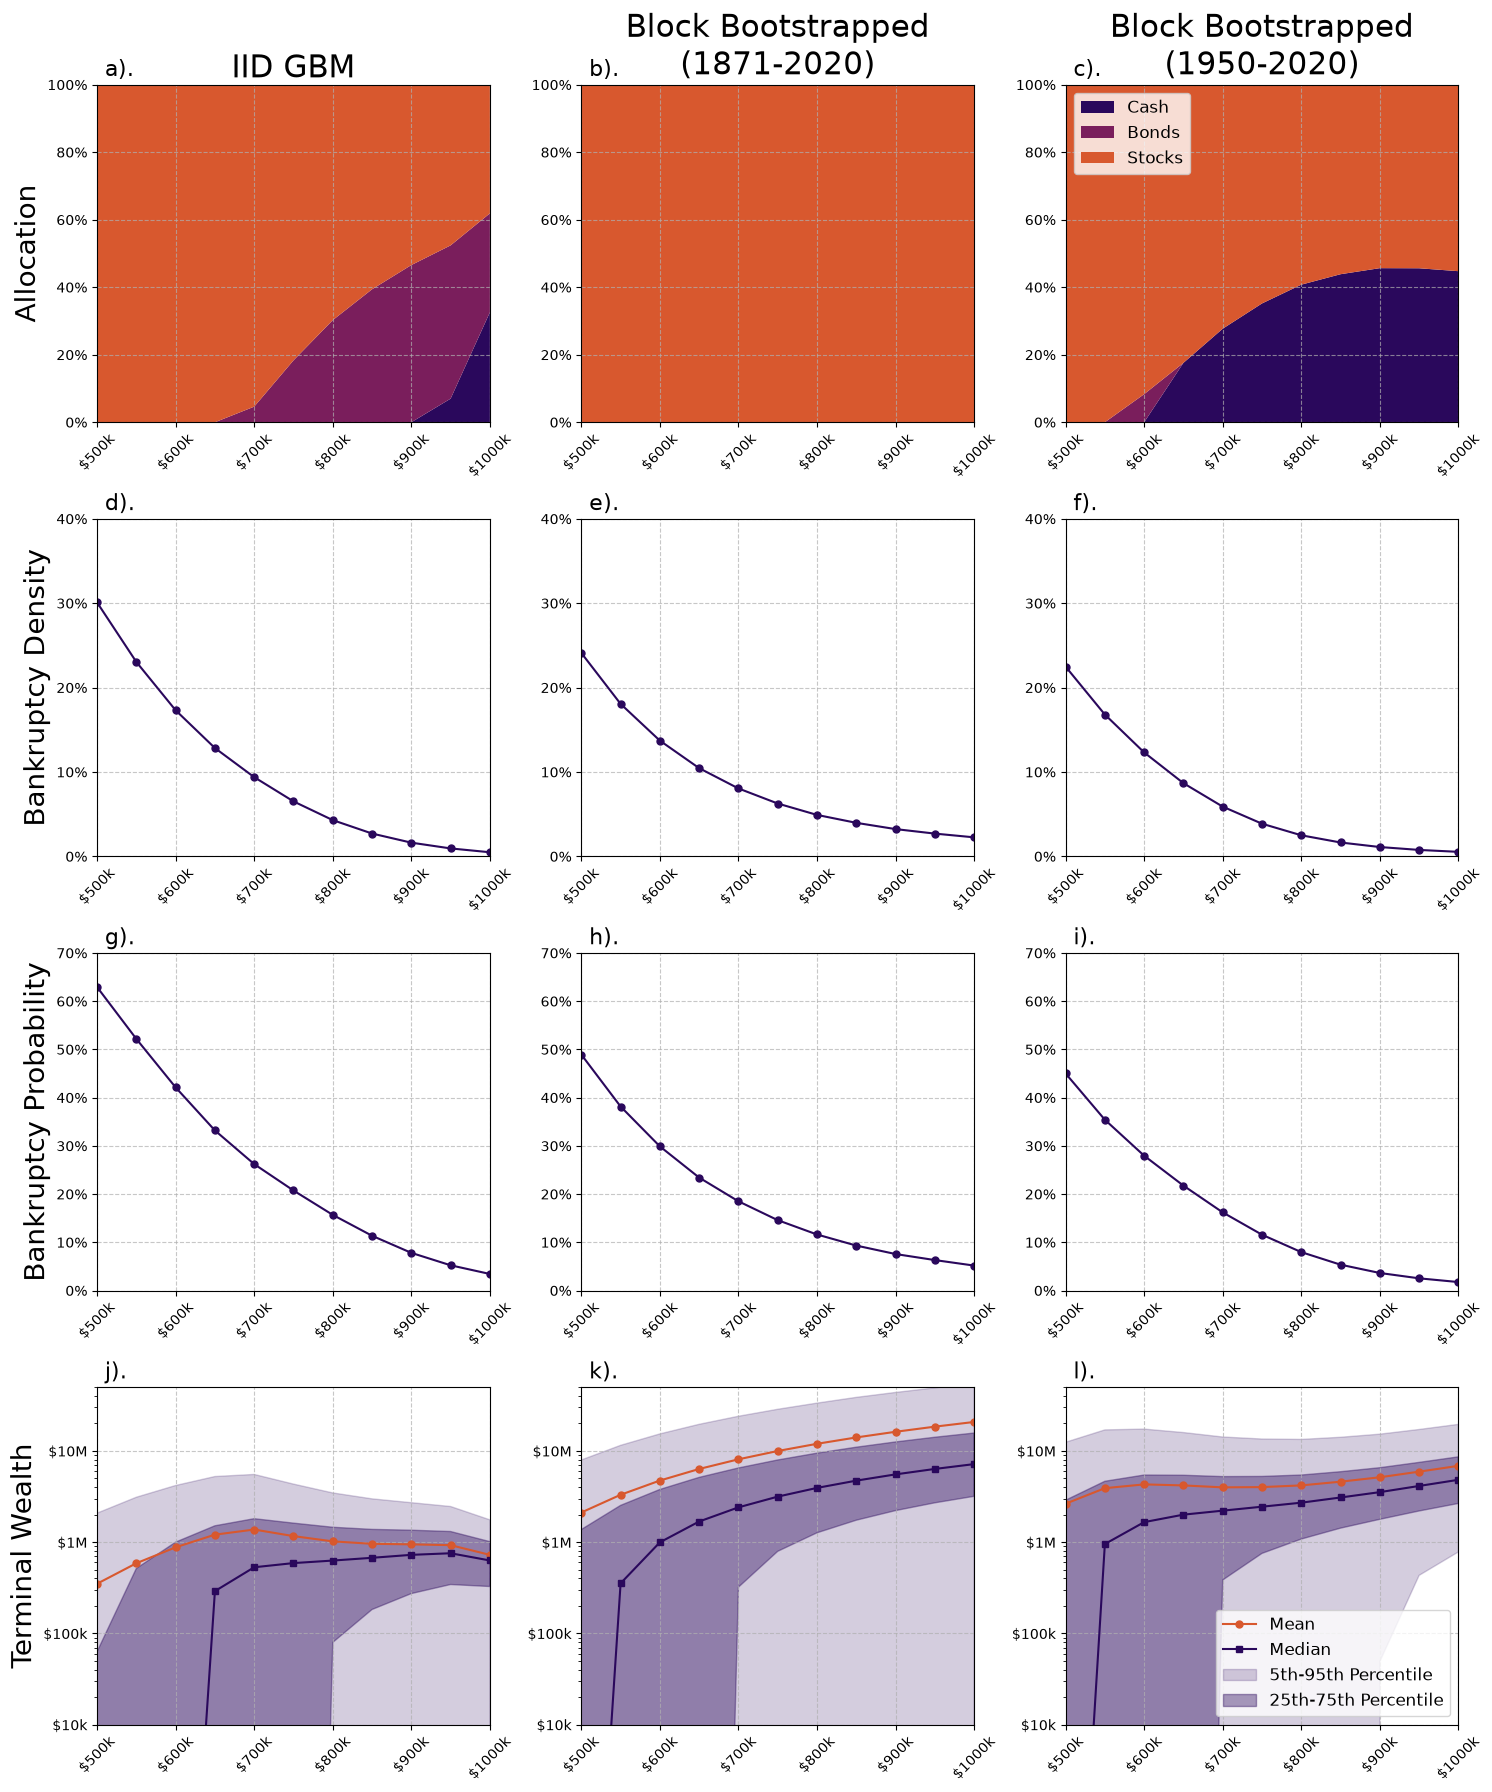

In [17]:
"""
plot layout:
Titles -> sampler name
Row 1: Allocation for each initial wealth
Row 2: Banruptcy density for each initial wealth
Row 3: Bankruptcy probability for each initial wealth
Row 4: Mean terminal wealth for each initial wealth
Row 
"""

policy_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1) & (pl.col('n_time_nodes') == 1) 
)

outcome_data = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1) & (pl.col('n_time_nodes') == 1) 
)

samplers_to_plot = [
    'cholesky',
    'block_bootstrapped',
    'block_bootstrapped_1950'
]

RETURN_SAMPLER_DISPLAY_NAMES = {
    "cholesky": "IID GBM",
    "block_bootstrapped": "Block Bootstrapped\n(1871-2020)",
    "block_bootstrapped_1950": "Block Bootstrapped\n(1950-2020)",
}

colors = {
    'Cash': '#2a085c',
    'Bonds': '#7a1e5c',
    'Stocks': '#d8582e',
}

percent_formatter = plt.FuncFormatter(lambda y, _: f'{y:.0%}')

def _currency_formatter(y: float, _: int) -> str:
    if not np.isfinite(y) or y <= 0:
        return ''
    if y >= 1_000_000:
        return f'${y / 1_000_000:.0f}M'
    if y >= 1_000:
        return f'${y / 1_000:.0f}k'
    return f'${y:.0f}'

currency_formatter = plt.FuncFormatter(_currency_formatter)

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(samplers_to_plot),
    figsize=(len(samplers_to_plot) * 5, 18),
    # sharex=True,
    # sharey='row'
)

def get_plot_letter(row_idx: int, col_idx: int) -> str:
    letter = chr(ord('a') + row_idx * len(samplers_to_plot) + col_idx)
    return f'{letter}).'

for col_idx, sampler in enumerate(samplers_to_plot):
    this_policy_data = policy_data.filter(pl.col('sampler') == sampler).sort('initial_wealth')

    this_outcome_data = outcome_data.filter(pl.col('sampler') == sampler).sort('initial_wealth')

    x = np.array(this_policy_data['initial_wealth'].to_list(), dtype=float)
    cash_points = np.array(this_policy_data['cash'].to_list(), dtype=float)
    bond_points = np.array(this_policy_data['bonds'].to_list(), dtype=float)
    stock_points = np.array(this_policy_data['stocks'].to_list(), dtype=float)

    allocation_axes = axes[0, col_idx]
    allocation_axes.stackplot(
        x,
        cash_points,
        bond_points,
        stock_points,
        labels=['Cash', 'Bonds', 'Stocks'],
        colors=[colors['Cash'], colors['Bonds'], colors['Stocks']],
    )
    allocation_axes.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=22, verticalalignment='top')
    if col_idx == 0:
        allocation_axes.set_ylabel('Allocation', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        allocation_axes.legend(loc='upper left', fontsize=12)
    allocation_axes.set_ylim(0, 1)
    allocation_axes.set_xlim(min(x), max(x))
    allocation_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    allocation_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)]) 
    allocation_axes.grid(linestyle='--', alpha=0.7)
    allocation_axes.set_yticks(np.arange(0, 1.2, 0.2))
    allocation_axes.yaxis.set_major_formatter(percent_formatter)
    allocation_axes.tick_params(axis='x', rotation=45)
    allocation_axes.text(0.02, 1.01, get_plot_letter(0, col_idx), transform=allocation_axes.transAxes, fontsize=16, va='bottom', ha='left')

    bd_axes = axes[1, col_idx]
    bd_axes.plot(
        x,
        this_outcome_data['bankruptcy_density'].to_list(),
        color=colors['Cash'],
        marker='o',
        markersize=5,
        label='Bankruptcy Density'
    )
    if col_idx == 0:
        bd_axes.set_ylabel('Bankruptcy Density', fontsize=20)
    bd_axes.set_ylim(0, 0.4)
    bd_axes.set_xlim(min(x), max(x))
    bd_axes.grid(linestyle='--', alpha=0.7)
    bd_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    bd_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)])
    bd_axes.tick_params(axis='x', rotation=45)
    bd_axes.set_yticks(np.arange(0, 0.5, 0.1))
    bd_axes.yaxis.set_major_formatter(percent_formatter)
    bd_axes.text(0.02, 1.01, get_plot_letter(1, col_idx), transform=bd_axes.transAxes, fontsize=16, va='bottom', ha='left')

    br_axes = axes[2, col_idx]
    br_axes.plot(
        x,
        this_outcome_data['bankruptcy_probability'].to_list(),
        color=colors['Cash'],
        marker='o',
        markersize=5,
        label='Bankruptcy Probability'
    )
    if col_idx == 0:
        br_axes.set_ylabel('Bankruptcy Probability', fontsize=20)
    br_axes.set_ylim(0, 0.7)
    br_axes.set_xlim(min(x), max(x))
    br_axes.grid(linestyle='--', alpha=0.7)
    br_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    br_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)])
    br_axes.tick_params(axis='x', rotation=45)
    br_axes.set_yticks(np.arange(0, 0.8, 0.1))
    br_axes.yaxis.set_major_formatter(percent_formatter)
    br_axes.text(0.02, 1.01, get_plot_letter(2, col_idx), transform=br_axes.transAxes, fontsize=16, va='bottom', ha='left')

    mtw_axes = axes[3, col_idx]
    mtw_axes.plot(
        x,
        this_outcome_data['mean_terminal_wealth'].to_list(),
        color=colors['Stocks'],
        marker='o',
        markersize=5,
        label='Mean'
    )
    mtw_axes.plot(
        x,
        (this_outcome_data['median_terminal_wealth'] + 1e-1).to_list(),
        color=colors['Cash'],
        marker='s',
        markersize=5,
        label='Median'
    )
    mtw_axes.fill_between(
        x,
        this_outcome_data['p05_terminal_wealth'].to_list(),
        this_outcome_data['p95_terminal_wealth'].to_list(),
        color=colors['Cash'],
        alpha=0.2,
        label='5th-95th Percentile'
    )
    mtw_axes.fill_between(
        x,
        this_outcome_data['p25_terminal_wealth'].to_list(),
        this_outcome_data['p75_terminal_wealth'].to_list(),
        color=colors['Cash'],
        alpha=0.4,
        label='25th-75th Percentile'
    )
    mtw_axes.text(0.02, 1.01, get_plot_letter(3, col_idx), transform=mtw_axes.transAxes, fontsize=16, va='bottom', ha='left')

    if col_idx == 0:
        mtw_axes.set_ylabel('Terminal Wealth', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        mtw_axes.legend(loc='lower right', fontsize=12)
    mtw_axes.set_ylim(1e4, 5e7)
    mtw_axes.set_xlim(min(x), max(x))
    mtw_axes.grid(linestyle='--', alpha=0.7)
    mtw_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    mtw_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)])
    mtw_axes.tick_params(axis='x', rotation=45)
    mtw_axes.set_yscale('log')
    mtw_axes.yaxis.set_major_formatter(currency_formatter)
    # mtw_axes.set_yticks([1, 1e3, 1e4, 1e5, 1e6, 1e7])
    # mtw_axes.set_yticklabels([f"${int(tick/1_000_000)}M" if tick >= 1e6 else f"${int(tick)}" for tick in [1, 1e3, 1e4, 1e5, 1e6, 1e7]])
    

fig.tight_layout(pad=1)
plt.savefig('./Plots/Fixed_Policy_Analysis.png', dpi=300)


In [4]:
this_outcome_data 

experiment_file,bankruptcy_probability,bankruptcy_density,mean_terminal_wealth,std_terminal_wealth,median_terminal_wealth,p05_terminal_wealth,p10_terminal_wealth,p25_terminal_wealth,p75_terminal_wealth,p90_terminal_wealth,p95_terminal_wealth,initial_wealth,n_time_nodes,n_wealth_nodes,sampler
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str
"""../Fixed Policy/Results\experi…",0.450195,0.224903,2.6372e6,6.0122e6,9.3731e-11,0.0,0.0,0.0,2.8770e6,7.6937e6,1.2427e7,500000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",0.3541775,0.168093,3.9032e6,7.7775e6,953214.656372,0.0,0.0,0.0,4.6441e6,1.0838e7,1.6981e7,550000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",0.2795775,0.123194,4.2943e6,7.5108e6,1.6571e6,0.0,0.0,0.0,5.4378e6,1.1510e7,1.7334e7,600000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",0.2175375,0.08676,4.1843e6,6.6651e6,2.0014e6,0.0,0.0,2.2093e-11,5.4080e6,1.0804e7,1.5883e7,650000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",0.1620475,0.05895,3.9843e6,5.7346e6,2.2131e6,0.0,0.0,384428.611614,5.2284e6,9.8855e6,1.4196e7,700000.0,1,1,"""block_bootstrapped_1950"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""../Fixed Policy/Results\experi…",0.0796425,0.025007,4.1861e6,5.1211e6,2.7069e6,0.0,3.2822e-11,1.0812e6,5.4399e6,9.6020e6,1.3359e7,800000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",0.0535825,0.016465,4.5986e6,5.2910e6,3.0855e6,0.0,355848.446386,1.4241e6,5.9125e6,1.0222e7,1.4098e7,850000.0,1,1,"""block_bootstrapped_1950"""
"""../Fixed Policy/Results\experi…",0.03636,0.011092,5.1391e6,5.6265e6,3.5323e6,49161.643454,705060.516048,1.7791e6,6.5434e6,1.1143e7,1.5249e7,900000.0,1,1,"""block_bootstrapped_1950"""
